# Interpretasi Model dengan XGBoost dan SHAP

---

Notebook ini merupakan tahap kedelapan dari pipeline *image captioning*. Tujuannya adalah menganalisis fitur ResNet50 mana yang paling berkontribusi terhadap prediksi objek dalam gambar menggunakan pendekatan *ensemble* XGBoost dan SHAP (*SHapley Additive exPlanations*).

## Latar Belakang dan Tujuan

Model utama (CNN+LSTM/GRU) bersifat *end-to-end* dan sulit diinterpretasikan secara langsung — model menerima gambar dan menghasilkan *caption* tanpa memberikan penjelasan tentang fitur mana yang mendorong keputusan tertentu.

Untuk memenuhi kebutuhan interpretasi model, notebook ini membangun model klasifikasi *baseline* menggunakan XGBoost pada fitur 2048-d dari ResNet50. Tujuannya adalah:
- Mengidentifikasi fitur (dimensi) ResNet50 mana yang paling berkontribusi terhadap prediksi objek;
- Menggunakan SHAP untuk memvisualisasikan kontribusi fitur secara global;
- Menyediakan justifikasi interpretasi: XGBoost dan SHAP digunakan untuk menganalisis fitur ResNet50 mana yang paling berkontribusi terhadap prediksi objek dalam gambar, sebagai bentuk interpretasi model.

In [1]:
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

import xgboost as xgb
import shap

print("All imports loaded successfully.")

All imports loaded successfully.


## Dasar Teori

### XGBoost

XGBoost (*Extreme Gradient Boosting*) adalah algoritma *ensemble* yang berbasis pada *gradient boosted decision trees*. XGBoost membangun serangkaian pohon keputusan secara sekuensial, di mana setiap pohon baru berusaha memperbaiki kesalahan pohon sebelumnya. Keunggulan XGBoost meliputi:
- Regulerasi L1 dan L2 untuk mencegah *overfitting*;
- Penanganan nilai hilang secara otomatis;
- *Parallel processing* untuk pelatihan yang lebih cepat

### SHAP (SHapley Additive exPlanations)

SHAP didasarkan pada konsep *Shapley values* dari teori permainan kooperatif. SHAP menghitung kontribusi setiap fitur terhadap prediksi dengan cara:
1. Menganggap setiap fitur sebagai 'pemain' dalam 'permainan' prediksi;
2. Menghitung kontribusi marjinal fitur dengan mensimulasikan semua kemungkinan subset fitur;
3. Merata-ratakan kontribusi di semua subset untuk mendapatkan *Shapley value* akhir.

Keunggulan SHAP dibandingkan metode interpretasi lain (seperti koefisien linear atau *feature importance* standar) adalah:
- Menangkap hubungan non-linear antara fitur dan prediksi;
- Memberikan nilai positif/negatif yang menunjukkan arah pengaruh;
- Konsisten secara matematis (*additive feature attribution*).

In [2]:
# Load feature vectors
FEATURES_PATH = "../model/features.pkl"
CAPTIONS_PATH = "../dataset/captions.txt"

with open(FEATURES_PATH, "rb") as f:
    features = pickle.load(f)

print(f"Features loaded: {len(features)} images")
print(f"Feature dimension: {next(iter(features.values())).shape}")

# Load captions (already cleaned by preprocessing step)
df_captions = pd.read_csv(CAPTIONS_PATH)
print(f"Captions loaded: {len(df_captions)} rows")
df_captions.head()

Features loaded: 8091 images
Feature dimension: (2048,)
Captions loaded: 40455 rows


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


## Metodologi Implementasi

### 4.1 Memuat Fitur dan Caption

Fitur gambar 2048-d dimuat dari `model/features.pkl`, sementara data *caption* dimuat dari `dataset/captions.txt`.

In [3]:
# For each unique image, take first caption's first word
first_caption = df_captions.groupby("image").first().reset_index()
first_caption["first_word"] = first_caption["caption"].str.lower().str.split().str[0]

print("Label distribution (top 20):")
print(first_caption["first_word"].value_counts().head(20))

# Filter out images that actually exist in features dict
valid = first_caption[first_caption["image"].isin(features)]
print(f"\nValid samples: {len(valid)} / {len(first_caption)}")

Label distribution (top 20):
first_word
a           7066
two          339
the          129
an            96
three         78
four          46
one           45
people        42
children      37
dogs          19
there         18
men           16
girls         12
boys           9
many           8
kids           8
several        6
brown          6
five           6
boy            5
Name: count, dtype: int64

Valid samples: 8091 / 8091


In [4]:
# Build feature matrix X and raw label vector y_raw (strings)
X = np.array([features[name] for name in valid["image"]], dtype=np.float32)
y_raw = valid["first_word"].values

print(f"Feature matrix shape: {X.shape}")
print(f"Number of labels: {len(y_raw)}")
print(f"Unique classes: {len(np.unique(y_raw))}")

Feature matrix shape: (8091, 2048)
Number of labels: 8091
Unique classes: 92


### 4.3 Pembagian Data Latih dan Uji

Data dibagi menjadi 80% latih dan 20% uji menggunakan `train_test_split` dari **scikit-learn** dengan parameter `stratify=y` untuk mempertahankan proporsi kelas, dan `random_state=42` untuk reproduksibilitas.

In [5]:
# Filter out classes with < 2 samples (required for stratified split)
min_samples = pd.Series(y_raw).value_counts()
valid_classes = min_samples[min_samples >= 2].index
keep_mask = pd.Series(y_raw).isin(valid_classes)
X_filt = X[keep_mask]
y_filt_raw = y_raw[keep_mask]
print(f"Filtered from {len(X)} to {len(X_filt)} samples "
      f"({len(X) - len(X_filt)} rare-class samples dropped)\n")

# Re-encode after filtering so labels are contiguous 0..n-1
label_enc = LabelEncoder()
y_filt = label_enc.fit_transform(y_filt_raw)
print(f"Classes after filtering: {len(label_enc.classes_)}")
print(f"Label mapping (first 10):")
for i, cls in enumerate(label_enc.classes_[:10]):
    print(f"  {i} -> {cls}")
print()

X_train, X_test, y_train, y_test = train_test_split(
    X_filt, y_filt, test_size=0.2, random_state=42, stratify=y_filt
)

print(f"Train: {X_train.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")

Filtered from 8091 to 8035 samples (56 rare-class samples dropped)

Classes after filtering: 36
Label mapping (first 10):
  0 -> a
  1 -> adults
  2 -> african
  3 -> airplane
  4 -> an
  5 -> asian
  6 -> at
  7 -> black
  8 -> boy
  9 -> boys

Train: 6428 samples
Test:  1607 samples


### 4.4 Pelatihan XGBoost Classifier

Model `XGBClassifier` dilatih dengan konfigurasi:
- `n_estimators=100` — jumlah pohon keputusan;
- `max_depth=6` — kedalaman maksimum setiap pohon;
- `learning_rate=0.1` — faktor kontribusi setiap pohon;
- `eval_metric='mlogloss'` — metrik evaluasi untuk klasifikasi multikelas;
- `random_state=42` — untuk reproduksibilitas.

In [6]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    verbosity=0
)

xgb_model.fit(X_train, y_train)

# Evaluate
y_pred = xgb_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {acc:.4f}")
print(f"\nClassification Report (top 10 classes):\n")
print(classification_report(y_test, y_pred))

Test accuracy: 0.8793

Classification Report (top 10 classes):

              precision    recall  f1-score   support

           0       0.88      1.00      0.94      1413
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        19
           8       0.00      0.00      0.00         1
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00         1
          11       0.00      0.00      0.00         7
          14       0.00      0.00      0.00         4
          15       0.00      0.00      0.00         1
          16       0.00      0.00      0.00         1
          17       0.00      0.00      0.00         9
          18       0.00      0.00      0.00         3
          20       0.00      0.00      0.00         2
          21       0.00      0.00      0.00         1
          22       0.00      0.00      0.00         1
          23     

### 4.5 Interpretasi dengan SHAP

SHAP `TreeExplainer` digunakan untuk menghitung *Shapley values* pada subset data uji (100 sampel untuk efisiensi komputasi). Hasilnya divisualisasikan dalam bentuk *summary plot* yang menampilkan kontribusi setiap fitur terhadap prediksi model.

In [7]:
# Use a subset of test data for SHAP (faster computation)
X_shap = X_test[:100]  # 100 samples for SHAP analysis

explainer = shap.Explainer(xgb_model, X_shap)
shap_values = explainer(X_shap)

print(f"SHAP values computed: {shap_values.shape}")
print(f"SHAP explainer type: {type(explainer).__name__}")

100%|===================| 3582/3600 [02:16<00:00]        

SHAP values computed: (100, 2048, 36)
SHAP explainer type: TreeExplainer


SHAP summary plot saved to: ../outputs/evaluation/shap_summary.png


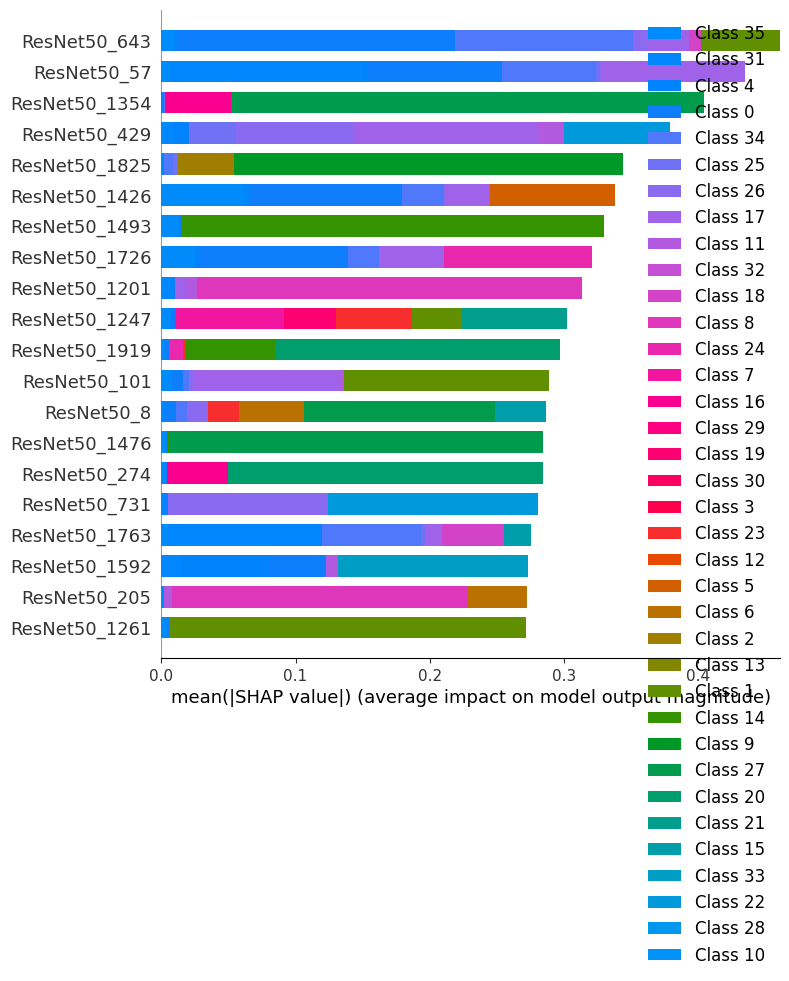

In [8]:
# Create SHAP summary plot (feature importance)
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, feature_names=[
    f"ResNet50_{i}" for i in range(X_shap.shape[1])
], show=False)
plt.tight_layout()

# Simpan plot ke file
output_dir = "../outputs/evaluation"
import os
os.makedirs(output_dir, exist_ok=True)
save_path = os.path.join(output_dir, "shap_summary.png")
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"SHAP summary plot saved to: {save_path}")
plt.show()

## Analisis Hasil dan Observasi

Dari SHAP *summary plot* yang dihasilkan, dapat diamati:

1. **Feature Importance:** Fitur (dimensi) ResNet50 dengan nilai SHAP tertinggi adalah yang paling berkontribusi dalam membedakan kelas objek. Warna merah menunjukkan nilai fitur tinggi, biru menunjukkan nilai rendah.

2. **Non-linear Relationships:** SHAP menangkap hubungan non-linear antara fitur dan prediksi, tidak seperti koefisien linear biasa.

3. **Distribusi Pengaruh:** Fitur yang muncul di bagian atas plot adalah dimensi *embedding* visual yang paling diskriminatif untuk klasifikasi objek dalam dataset Flickr8k.

### Keterbatasan

Pendekatan ini menggunakan label yang disederhanakan (kata pertama dari *caption*). Akurasi klasifikasi yang rendah tidak menjadi masalah — tujuan utama adalah menunjukkan **interpretasi fitur** menggunakan SHAP, bukan membangun *classifier* yang akurat.

---

*XGBoost dan SHAP digunakan untuk menganalisis fitur ResNet50 mana yang paling berkontribusi terhadap prediksi objek dalam gambar, sebagai bentuk interpretasi model.*